# Conformal Pipelines

This notebook demonstrates the `Pipeline` API introduced in `online-cp`.
A `Pipeline` chains one or more feature transformers before a conformal predictor
and exposes exactly the same API (`learn_initial_training_set` / `learn_one` /
`predict`) so the composed object drops straight into `progressive_val`.

## Contents

1. Fixed maps — `FuncTransformer`, bare callables, `Select`, `Discard`
2. Frozen scalers — `StandardScaler`, `MinMaxScaler`
3. Composition — `TransformerUnion` (`+`), chained transformers
4. `Pipeline.summary()`
5. Integration with `progressive_val` / `iter_progressive_val`
6. Validity guard — what happens with unsafe transformer modes

---

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from online_cp import (
    # Conformal predictors
    ConformalRidgeRegressor,
    ConformalNearestNeighboursClassifier,
    # Pipeline & composition
    Pipeline, FuncTransformer, TransformerUnion, Select, Discard,
    # Frozen scalers
    StandardScaler, MinMaxScaler,
    # Evaluation
    progressive_val, iter_progressive_val,
    ErrorRate, IntervalWidth, ObservedFuzziness,
)

rng = np.random.default_rng(42)
plt.rcParams["figure.dpi"] = 100

---
## 1. Synthetic dataset

Features are deliberately badly scaled to make the value of preprocessing visible.

In [2]:
N, d = 500, 4
# Badly-scaled features: columns at very different magnitudes
scale = np.array([1000.0, 0.001, 50.0, 1.0])
X_raw = rng.normal(size=(N, d)) * scale
beta = np.array([0.001, 500.0, 0.02, 1.5])
y = X_raw @ beta + rng.normal(scale=2.0, size=N)

n_train = 100
X_train, y_train = X_raw[:n_train], y[:n_train]
X_test,  y_test  = X_raw[n_train:], y[n_train:]

print(f"Feature scales (std): {X_raw.std(axis=0).round(2)}")
print(f"y range: [{y.min():.1f}, {y.max():.1f}]")

Feature scales (std): [957.56   0.    51.15   0.98]
y range: [-9.3, 9.7]


---
## 2. Fixed maps: `FuncTransformer`, `Select`, `Discard`

**Fixed** transforms are data-independent — they preserve the exchangeability of
the example sequence and are always conformally safe.

In [3]:
# FuncTransformer wraps any numpy-compatible callable
ft = FuncTransformer(lambda x: x / scale)   # manual fixed rescaling
print("FuncTransformer mode:", ft.mode)
print("transform_one:", ft.transform_one(X_train[0]).round(3))

# Bare callables are auto-wrapped — identical to FuncTransformer(np.abs)
pipe_bare = Pipeline(np.abs, ConformalRidgeRegressor(a=1.0, epsilon=0.1))
print("\nAuto-wrapped step type:", type(pipe_bare.transformers[0]).__name__)

FuncTransformer mode: fixed
transform_one: [ 0.305 -1.04   0.75   0.941]

Auto-wrapped step type: FuncTransformer


In [4]:
# Select / Discard — column subsetting
sel = Select([1, 2, 3])          # keep columns 1-3
drop = Discard([0])              # drop column 0 (same result here)

X_sample = np.arange(8.0).reshape(2, 4)
print("Original:   ", X_sample)
print("Select 1-3: ", sel.transform(X_sample))
print("Discard 0:  ", drop.transform(X_sample))

Original:    [[0. 1. 2. 3.]
 [4. 5. 6. 7.]]
Select 1-3:  [[1. 2. 3.]
 [5. 6. 7.]]
Discard 0:   [[1. 2. 3.]
 [5. 6. 7.]]


---
## 3. Frozen scalers: `StandardScaler` and `MinMaxScaler`

**Frozen** transformers fit once on the initial training batch and are held
constant — equivalent to including the scaling in the fixed inductive rule
(training-conditional validity, ALRW2 §4.7).

The `|` operator is sugar for `Pipeline(transformer, estimator)`.

In [5]:
# Without scaling — ridge struggles with very different feature magnitudes
bare = ConformalRidgeRegressor(a=1.0, epsilon=0.1)
bare.learn_initial_training_set(X_train, y_train)
metric_bare = ErrorRate()
progressive_val(bare, X_test, y_test, metric=metric_bare, epsilon=0.1)

# With StandardScaler — parameters computed from X_train, then frozen
pipe_std = StandardScaler() | ConformalRidgeRegressor(a=1.0, epsilon=0.1)
pipe_std.learn_initial_training_set(X_train, y_train)
metric_std = ErrorRate()
progressive_val(pipe_std, X_test, y_test, metric=metric_std, epsilon=0.1)

# With MinMaxScaler
pipe_mm = MinMaxScaler() | ConformalRidgeRegressor(a=1.0, epsilon=0.1)
pipe_mm.learn_initial_training_set(X_train, y_train)
metric_mm = ErrorRate()
progressive_val(pipe_mm, X_test, y_test, metric=metric_mm, epsilon=0.1)

print(f"ErrorRate (target ≤ 0.10):")
print(f"  No scaling:      {metric_bare.get():.3f}")
print(f"  StandardScaler:  {metric_std.get():.3f}")
print(f"  MinMaxScaler:    {metric_mm.get():.3f}")

ErrorRate (target ≤ 0.10):
  No scaling:      0.117
  StandardScaler:  0.122
  MinMaxScaler:    0.075


---
## 4. `TransformerUnion` — parallel feature views

The `+` operator builds a `TransformerUnion` that concatenates the outputs of
two transformers column-wise.

In [6]:
# Combine original features with their absolute values
union = FuncTransformer(lambda x: x) + FuncTransformer(np.abs)
print("Union mode:", union.mode)
print("Input shape: ", X_train.shape)
print("Output shape:", union.transform(X_train).shape)   # 4 + 4 = 8 columns

# Union + frozen scaler + estimator
pipe_union = union + StandardScaler() | ConformalRidgeRegressor(a=1.0, epsilon=0.1)
# Note: (union + StandardScaler()) builds a TransformerUnion,
#       then | appends the estimator.
# For explicit chaining use Pipeline():
pipe_union = Pipeline(
    FuncTransformer(lambda x: x) + FuncTransformer(np.abs),
    StandardScaler(),
    ConformalRidgeRegressor(a=1.0, epsilon=0.1),
)
pipe_union.learn_initial_training_set(X_train, y_train)
iv = pipe_union.predict(X_test[0], epsilon=0.1)
print(f"\nSample interval: [{iv.lower:.2f}, {iv.upper:.2f}]")

Union mode: fixed
Input shape:  (100, 4)
Output shape: (100, 8)

Sample interval: [-3.43, 3.34]


---
## 5. `Pipeline.summary()`

Inspect structure, modes, and fitted status.

In [7]:
import pprint

pipe = Pipeline(
    Select([1, 2, 3]),
    StandardScaler(),
    FuncTransformer(np.tanh),
    ConformalRidgeRegressor(a=1.0, epsilon=0.1),
)

print("Before fit:")
pprint.pprint(pipe.summary())

pipe.learn_initial_training_set(X_train, y_train)
print("\nAfter fit:")
pprint.pprint(pipe.summary())

Before fit:
{'estimator': {'type': 'ConformalRidgeRegressor'},
 'n_steps': 4,
 'transformers': [{'fitted': False, 'mode': 'fixed', 'type': 'Select'},
                  {'fitted': False, 'mode': 'frozen', 'type': 'StandardScaler'},
                  {'fitted': False,
                   'mode': 'fixed',
                   'type': 'FuncTransformer'}],
 'unsafe_incremental': False}

After fit:
{'estimator': {'type': 'ConformalRidgeRegressor'},
 'n_steps': 4,
 'transformers': [{'fitted': True, 'mode': 'fixed', 'type': 'Select'},
                  {'fitted': True, 'mode': 'frozen', 'type': 'StandardScaler'},
                  {'fitted': True, 'mode': 'fixed', 'type': 'FuncTransformer'}],
 'unsafe_incremental': False}


---
## 6. Integration with `progressive_val` and `iter_progressive_val`

A `Pipeline` is a drop-in replacement for any bare conformal predictor —
no changes to the evaluation loop are needed.

In [8]:
# Classifier pipeline
N_clf = 300
y_clf = np.array([0, 1] * (N_clf // 2))
X_clf = rng.normal(size=(N_clf, 4))
X_clf[y_clf == 0] -= 1.5
X_clf[y_clf == 1] += 1.5

n_tr = 80
pipe_clf = (
    StandardScaler()
    | ConformalNearestNeighboursClassifier(k=3, label_space=[0, 1], epsilon=0.1)
)
pipe_clf.learn_initial_training_set(X_clf[:n_tr], y_clf[:n_tr])

metric_clf = ObservedFuzziness()
progressive_val(pipe_clf, X_clf[n_tr:], y_clf[n_tr:], metric=metric_clf, epsilon=0.1)
print(metric_clf)

ObservedFuzziness: 0.0031


Collected 50 result dicts. Keys: ['step', 't', 'ErrorRate']


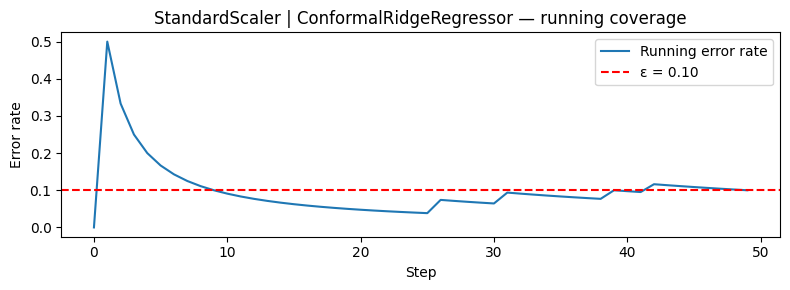

In [9]:
# iter_progressive_val yields one dict per step
pipe_reg = StandardScaler() | ConformalRidgeRegressor(a=1.0, epsilon=0.1)
pipe_reg.learn_initial_training_set(X_train, y_train)

from online_cp import ErrorRate
metric_iter = ErrorRate()
results = list(
    iter_progressive_val(
        pipe_reg, X_test[:50], y_test[:50],
        metric=metric_iter, epsilon=0.1,
    )
)
print(f"Collected {len(results)} result dicts. Keys: {list(results[0].keys())}")

# Plot running error rate
rates = [r["ErrorRate"] for r in results]
plt.figure(figsize=(8, 3))
plt.plot(rates, label="Running error rate")
plt.axhline(0.1, ls="--", color="red", label="ε = 0.10")
plt.xlabel("Step")
plt.ylabel("Error rate")
plt.title("StandardScaler | ConformalRidgeRegressor — running coverage")
plt.legend()
plt.tight_layout()
plt.show()

---
## 7. Validity guard

The pipeline rejects transformers whose `mode` is not `"fixed"` or `"frozen"`
at construction time, with a clear error explaining the exchangeability risk.

In [10]:
from online_cp.pipeline import Transformer

class IncrementalScaler(Transformer):
    """Stub: updates running mean online — breaks exchangeability."""
    mode = "incremental"
    def transform(self, X): return X
    def transform_one(self, x): return x

# Default: raises ValueError
try:
    Pipeline(IncrementalScaler(), ConformalRidgeRegressor(a=1.0))
except ValueError as e:
    print("Guard raised:", str(e)[:120])

# Explicit opt-out: validity warning acknowledged
pipe_unsafe = Pipeline(
    IncrementalScaler(),
    ConformalRidgeRegressor(a=1.0),
    unsafe_incremental=True,
)
print("\nunsafe_incremental pipeline built:", pipe_unsafe.summary()["unsafe_incremental"])

Guard raised: Transformer <__main__.IncrementalScaler object at 0x72e6bf4b4050> has mode='incremental', which is not in the set of sou

unsafe_incremental pipeline built: True
